<a href="https://colab.research.google.com/github/AthulkrishnaR/Ml-lab/blob/main/exp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_squared_error,r2_score

In [ ]:
diabetes=load_diabetes()

x=diabetes.data
y=diabetes.target

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

print("Training samples:",x_train.shape[0])
print("Testing samples:",x_test.shape[0])

Training samples: 353
Testing samples: 89


In [ ]:
linear_model=LinearRegression()
linear_model.fit(x_train_scaled,y_train)

y_pred_linear=linear_model.predict(x_test_scaled)

print("Linear Regression")
print("MSE:",mean_squared_error(y_test,y_pred_linear))
print("R2 Score:",r2_score(y_test,y_pred_linear))

Linear Regression
MSE: 2900.1936284934823
R2 Score: 0.45260276297191926


In [ ]:
ridge = Ridge()

param_grid={'alpha':[0.01,0.1,1,10,100]}

ridge_cv=GridSearchCV(ridge,param_grid,cv=5)
ridge_cv.fit(x_train_scaled,y_train)

best_ridge=ridge_cv.best_estimator_

y_pred_ridge=best_ridge.predict(x_test_scaled)

print("Best Alpha for Ridge:",ridge_cv.best_params_['alpha'])
print("MSE=", mean_squared_error(y_test,y_pred_ridge))
print("R2 Score:",r2_score(y_test,y_pred_ridge))

Best Alpha for Ridge: 10
MSE= 2875.7787184218428
R2 Score: 0.4572109567780849


In [ ]:
lasso=Lasso(max_iter=10000)

lasso_cv=GridSearchCV(lasso,param_grid,cv=5)
lasso_cv.fit(x_train_scaled,y_train)

best_lasso=lasso_cv.best_estimator_

y_pred_lasso=best_lasso.predict(x_test_scaled)

print("Best Alpha for Lasso:",lasso_cv.best_params_['alpha'])
print("MSE=",mean_squared_error(y_test,y_pred_lasso))
print("R2 Score:",r2_score(y_test,y_pred_lasso))

Best Alpha for Lasso: 1
MSE= 2824.568094049959
R2 Score: 0.46687670944102466


In [ ]:
results=pd.DataFrame({
    'Model':['Linear Regression','Ridge','Lasso'],
    'MSE':[mean_squared_error(y_test,y_pred_linear),mean_squared_error(y_test,y_pred_ridge),mean_squared_error(y_test,y_pred_lasso)],
    'R2 Score':[r2_score(y_test,y_pred_linear),r2_score(y_test,y_pred_ridge),r2_score(y_test,y_pred_lasso)]
})
print(results)

               Model          MSE  R2 Score
0  Linear Regression  2900.193628  0.452603
1              Ridge  2875.778718  0.457211
2              Lasso  2824.568094  0.466877


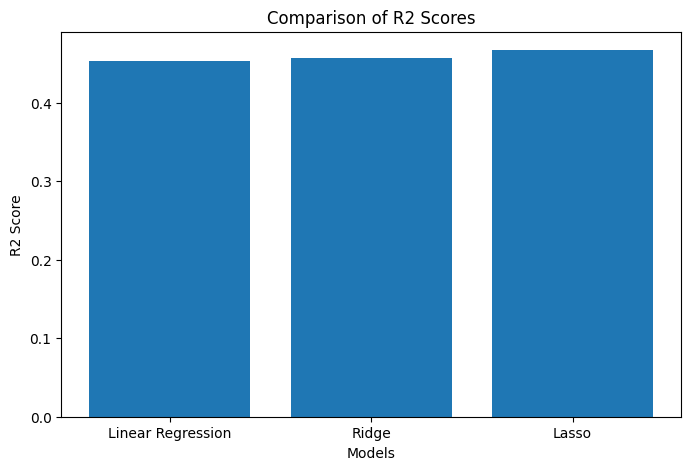

In [ ]:
plt.figure(figsize=(8,5))

models=['Linear Regression','Ridge','Lasso']
r2_scores=[r2_score(y_test,y_pred_linear),r2_score(y_test,y_pred_ridge),r2_score(y_test,y_pred_lasso)]
plt.bar(models,r2_scores)
plt.xlabel('Models')
plt.ylabel('R2 Score')
plt.title('Comparison of R2 Scores')
plt.show()